Let's right down the thirteen equations.

We also know that there are seven equations that when squared give a six digit number, and that there are six equations that when cubed give a six digit number. Since the equations are in sequential order, the cubes must come before the squares.

In [ ]:
import itertools
import more_itertools


## Numbers that if cubed give a six-digit number with no zeros
S1 = {x for x in range(47, 100) if '0' not in str(x * x * x)}

## Numbers that if squared give a six-digit number with no zeros
S2 = {x for x in range(317, 1000) if '0' not in str(x * x)}

## These must all give a result in S1
def eq01(*, B, E, **_):
    return B * E
def eq02(*, B, D, E, **_):
    return D - B * E
def eq03(*, A, C, F, **_):
    return A * (F + C)
def eq04(*, E, F, **_):
    return E * F
def eq05(*, B, C, F, **_):
    return C * (B + F)
def eq06(*, C, D, F, **_):
    return D - (F + C)

## These must all give a result in S2.
def eq07(*, A, C, D, **_):
    return C * D - A
def eq08(*, A, C, D, **_):
    return A * (D - C * A)
def eq09(*, A, B, C, E, F, **_):
    return B * (F * C + A - E)
def eq10(*, A, B, **_):
    return A * B * B
def eq11(*, B, D, E, F, **_):
    return E * (D - F) - B
def eq12(*, A, B, C, D, E, **_):
    return A * (D + E * (B + C))
def eq13(*, A, C, D, E, **_):
    return D * (A + C) - E


In [ ]:
def get_values():
    for B, E in itertools.product(range(1, max(S1) + 1), repeat=2):
        # Equation 1 limits B and E so that they multiply to be a member of S1
        if (x01 := eq01(B=B, E=E)) in S1:
            # A ≤ 50 from Equation 3.  Equation 10 is quite limiting.
            for A in range(1, 50):
                if (x10 := eq10(A=A, B=B, E=E)) in S2:
                    # F's lower bound is comparing eq01 to eq04.
                    # F's upper bound is that F * E is in S1
                    for F in range(B, (100 // E) + 1):
                        if (x04 := eq04(A=A, B=B, E=E, F=F)) in S1 and x04 > x01:
                            # From Equation 5, C <= 50
                            for C in range(1, 51):
                                x03 = eq03(A=A, B=B, C=C, E=E, F=F)
                                if not (x03 in S1 and x01 < x03 < x04): continue
                                x05 = eq05(A=A, B=B, C=C, E=E, F=F)
                                if not (x05 in S1 and x04 < x05): continue
                                x09 = eq09(A=A, B=B, C=C, E=E, F=F)
                                if not (x09 in S2 and x09 < x10): continue
                                # eq2 limits D's values
                                for t in (x for x in S1 if x01 < x < x03):
                                    D = t + B * E
                                    equations = [eq01, eq02, eq03, eq04, eq05, eq06, eq07, eq08,
                                                 eq09, eq10, eq11, eq12, eq13]
                                    values = [eq(A=A, B=B, C=C, D=D, E=E, F=F) for eq in equations]
                                    okay = (all(x in S1 for x in values[:6]) and
                                            all(x in S2 for x in values[6:]) and
                                            all(x < y for x, y in itertools.pairwise(values)))
                                    if okay:
                                        yield {'A': A, 'B': B, 'C': C, 'D': D, 'E': E, 'F': F,
                                               'values': values}

results = list(get_values())
print(len(results))

We've got a single solution.

In [ ]:
values = results[0]['values']
cubes = [i * i * i for i in values[:6]]
squares = [i * i for i in values[6:]]
print(cubes)
print(squares)

The 6 rows and 6 columsn use the same digits.  The extra square digits must be the digits in the diagonal.

In [ ]:
from collections import Counter

square_digits = Counter(letter for square in squares for letter in str(square))
cube_digits = Counter(letter for cube in cubes for letter in str(cube))
for digit in range(0, 10):
    sd = square_digits[str(digit)]
    cd = cube_digits[str(digit)]
    print(f'{digit} {sd:2d} {cd:2d} {sd - cd:2}')

The diagonal must have the digits 112225.  We might have had to permute it, but in this case we don't. The value `112225` is one of our squares, so it must be the diagonal.
```
rows = [166375, 195112, 262144, 274625, 373248, 912673]<
columns/diagonals = [112225, 163216, 174724, 234256, 239121, 535824, 617796]

1 * * * * *
* 1 * * * *
* * 2 * * *
* * * 2 * *
* * * * 2 *
* * * * * 5

Second row must be 912673
Third row must now be 262144
Fourth row must be 373248
Fifth row must be 274625
Sixth row must be 166375
First row must be 195112

1 9 5 1 1 2
9 1 2 6 7 3
2 6 2 1 4 4
3 7 3 2 4 8
2 7 4 6 2 5
1 6 6 3 7 5
```

Let's double check that the columns match:

```
112225: Diagonal
163216: Column 4
174274: Column 5
234256: Column 3
239121: Column 1
535824: Column 6
617796: Column 3
```

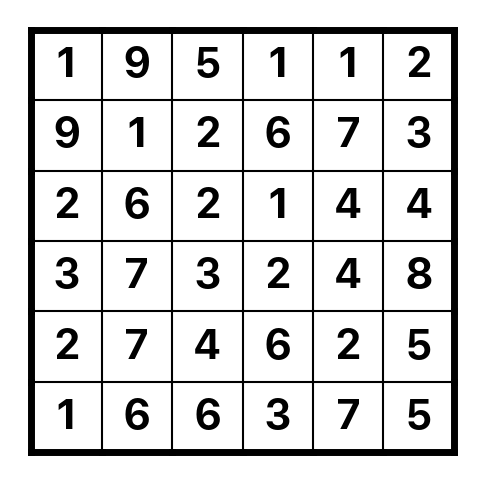

In [11]:
from matplotlib import pyplot as plt
import itertools

RESULT = """
1 9 5 1 1 2
9 1 2 6 7 3
2 6 2 1 4 4
3 7 3 2 4 8
2 7 4 6 2 5
1 6 6 3 7 5"""

digits = [x for x in RESULT if '0' <= x <= '9']
squares = itertools.product(range(1, 7), repeat=2)
grid = dict(zip(squares, digits))
# draw_grid(max_row=7, max_column=7, location_to_entry=grid)

_, axes = plt.subplots(1, 1, figsize=(6, 6), dpi=100)
# set (1,1) as the top-left corner, and (max_column, max_row) as the bottom right.
axes.axis((1, 7, 7, 1))
axes.axis('equal')
axes.axis('off')

for row, column in itertools.product(range(1, 7 + 1), range(1, 7 + 1)):
    this_exists = (row, column) in grid
    left_exists = (row, column - 1) in grid
    above_exists = (row - 1, column) in grid
    if this_exists or left_exists:
        width = (5 if this_exists != left_exists else None)
        axes.plot([column, column], [row, row + 1], 'black', linewidth=width)
    if this_exists or above_exists:
        width = (5 if this_exists != above_exists else None)
        axes.plot([column, column + 1], [row, row], 'black', linewidth=width)

points_per_data = 60

# Fill in the values
for (row, column), entry in grid.items():
    axes.text(column + 1 / 2, row + 1 / 2, entry,
              color='black',
              fontsize=points_per_data / 2, fontweight='bold',
              fontfamily="SF Pro Text",
              va='center', ha='center')